# Modelling

This notebook compares an interpretable linear regression model with a
nonlinear random forest model for predicting taxi and ride-hailing demand.
The target variable is log trip count at service-zone-hour level.

## Setup

Import the Python, Spark, plotting, and modelling libraries used in this notebook.

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("/mnt/d/ADS_proj1")
ANALYSIS_PATH = PROJECT_ROOT / "data" / "processed" / "analysis_zone_hour"

spark = (
    SparkSession.builder
    .appName("MAST30034 Project 1 Modelling")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.sql.shuffle.partitions", "24")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

## Build Modelling Table

Read the processed zone-hour table and create a modelling dataset without airport zones.

In [17]:
analysis_df = spark.read.parquet(str(ANALYSIS_PATH))

model_df = (
    analysis_df
    .filter(F.col("borough").isin(["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]))
    .filter(~F.col("zone").isin(["JFK Airport", "LaGuardia Airport", "Newark Airport"]))
    .withColumn("hour_of_day", F.hour("pickup_hour"))
    .withColumn("log_trip_count", F.log1p("trip_count"))
    .select(
        "log_trip_count",
        "trip_count",
        "service_type",
        "borough",
        "subway_access_level",
        "subway_station_count",
        "nearest_subway_distance_km",
        "hour_of_day",
        "avg_trip_miles",
        "avg_trip_duration_minutes",
        "avg_earning_per_hour",
    )
)

model_pd = pd.DataFrame(
    [row.asDict() for row in model_df.collect()]
)

model_pd.head()

,log_trip_count,trip_count,service_type,borough,subway_access_level,subway_station_count,nearest_subway_distance_km,hour_of_day,avg_trip_miles,avg_trip_duration_minutes,avg_earning_per_hour
0,2.772589,15,yellow,Manhattan,high,5,0.158020,0,2.640667,11.816667,132.359356
1,1.609438,4,yellow,Manhattan,high,2,0.319454,0,2.185000,9.883333,124.123948
2,2.079442,7,yellow,Manhattan,high,2,0.253391,0,1.862857,10.323810,116.227633
3,1.098612,2,yellow,Manhattan,high,6,0.471451,0,2.855000,13.450000,96.548016
4,2.708050,14,yellow,Manhattan,medium,1,0.342523,0,2.786429,10.244048,138.871101


## Train-Test Split

Define the response variable, feature groups, and hold-out test set.

In [18]:
target = "log_trip_count"

categorical_features = [
    "service_type",
    "borough",
    "subway_access_level",
]

numeric_features = [
    "subway_station_count",
    "nearest_subway_distance_km",
    "hour_of_day",
    "avg_trip_miles",
    "avg_trip_duration_minutes",
    "avg_earning_per_hour",
]

X = model_pd[categorical_features + numeric_features]
y = model_pd[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30034,
)

## Shared Feature Preprocessing

One-hot encode categorical variables and pass numeric variables through unchanged.

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)

## OLS Linear Regression

Fit a simple interpretable linear model for log trip demand.

In [20]:
ols_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

ols_model.fit(X_train, y_train)

ols_pred = ols_model.predict(X_test)

## OLS Evaluation

Evaluate OLS on the held-out test set using MAE, RMSE, and R-squared.

In [21]:
def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


ols_metrics = evaluate_model(y_test, ols_pred)
ols_metrics

{'MAE': 0.7956306134775131,
 'RMSE': 1.031586638218883,
 'R2': 0.6040842032256963}

## Random Forest

Fit a nonlinear model that can capture interactions between location, time, and service type.

In [22]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=20,
                random_state=30034,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## Random Forest Evaluation

Evaluate the random forest model on the same test set.

In [23]:
rf_metrics = evaluate_model(y_test, rf_pred)
rf_metrics

{'MAE': 0.4253888373346478,
 'RMSE': 0.5897633489562936,
 'R2': 0.870596216905568}

## Model Comparison

Compare the linear and nonlinear models using the same evaluation metrics.

In [24]:
model_comparison = pd.DataFrame(
    [
        {"model": "OLS Linear Regression", **ols_metrics},
        {"model": "Random Forest", **rf_metrics},
    ]
)

model_comparison

,model,MAE,RMSE,R2
0,OLS Linear Regression,0.795631,1.031587,0.604084
1,Random Forest,0.425389,0.589763,0.870596


## Random Forest Feature Importance

Extract feature importance values to see which predictors are most useful for demand prediction.

In [25]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

rf_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": rf_model.named_steps["model"].feature_importances_,
    }
).sort_values("importance", ascending=False)

rf_importance.head(15)

,feature,importance
1,categorical__service_type_hvfhv,0.366995
5,categorical__borough_Manhattan,0.185418
11,numeric__subway_station_count,0.095523
14,numeric__avg_trip_miles,0.086147
12,numeric__nearest_subway_distance_km,0.069677
15,numeric__avg_trip_duration_minutes,0.066784
13,numeric__hour_of_day,0.058619
7,categorical__borough_Staten Island,0.031533
2,categorical__service_type_yellow,0.016000
16,numeric__avg_earning_per_hour,0.015596


## Random Forest Importance Plot

Visualise the strongest predictors from the random forest model.

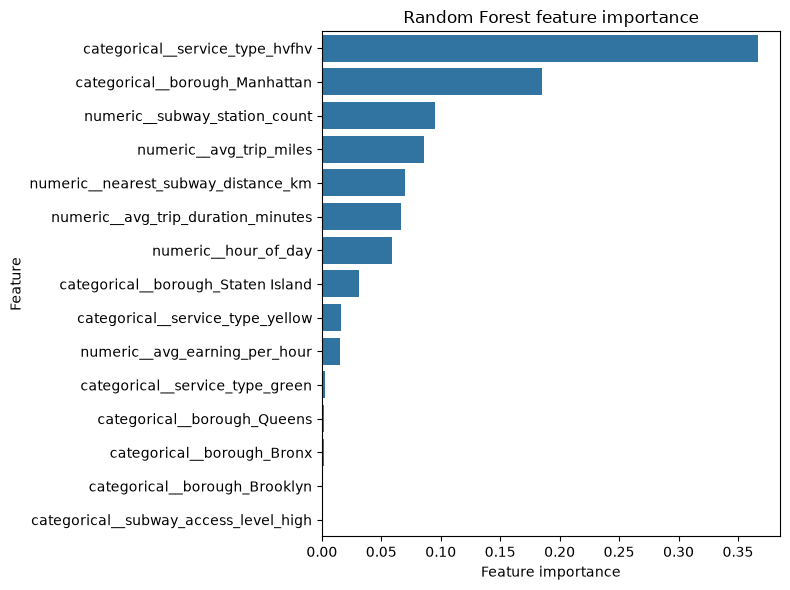

In [26]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=rf_importance.head(15),
    x="importance",
    y="feature",
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

## Initial OLS Coefficients

Inspect the first OLS coefficient table. The baseline OLS below is easier to interpret for the report.

In [27]:
ols_feature_names = ols_model.named_steps["preprocessor"].get_feature_names_out()
ols_coefficients = ols_model.named_steps["model"].coef_

ols_coef = pd.DataFrame(
    {
        "feature": ols_feature_names,
        "coefficient": ols_coefficients,
    }
).sort_values("coefficient", ascending=False)

ols_coef

,feature,coefficient
1,categorical__service_type_hvfhv,1.919263
5,categorical__borough_Manhattan,0.988876
10,categorical__subway_access_level_medium,0.131188
8,categorical__subway_access_level_high,0.104856
11,numeric__subway_station_count,0.096978
13,numeric__hour_of_day,0.036200
12,numeric__nearest_subway_distance_km,0.018377
15,numeric__avg_trip_duration_minutes,0.009726
16,numeric__avg_earning_per_hour,0.000043
4,categorical__borough_Brooklyn,-0.015933


## Initial OLS Coefficient Plot

Visualise the initial coefficient directions.

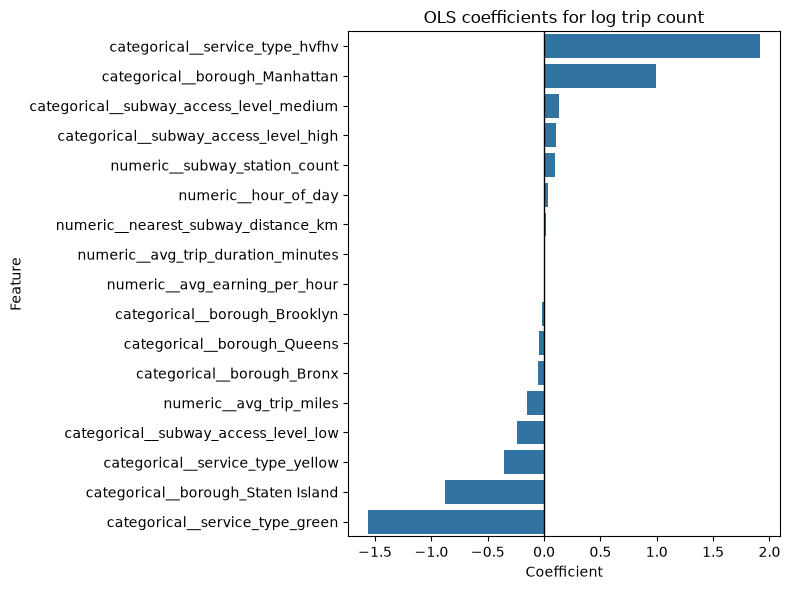

In [28]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=ols_coef,
    x="coefficient",
    y="feature",
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("OLS coefficients for log trip count")
plt.tight_layout()
plt.show()

## OLS With Reference Categories

Refit OLS with explicit baseline categories so the coefficients are
easier to explain. The reference groups are green taxi, Bronx, and
low subway accessibility.

In [29]:
baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                categories=[
                    ["green", "hvfhv", "yellow"],
                    ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"],
                    ["low", "medium", "high"],
                ],
                drop="first",
                handle_unknown="ignore",
            ),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)

## Baseline OLS Model

Train the baseline-coded OLS model and evaluate it on the same test
set. The predictive performance should be very close to the original OLS.

In [30]:
baseline_ols_model = Pipeline(
    steps=[
        ("preprocessor", baseline_preprocessor),
        ("model", LinearRegression()),
    ]
)

baseline_ols_model.fit(X_train, y_train)

baseline_ols_pred = baseline_ols_model.predict(X_test)
baseline_ols_metrics = evaluate_model(y_test, baseline_ols_pred)

baseline_ols_metrics

{'MAE': 0.7956306134775146,
 'RMSE': 1.031586638218883,
 'R2': 0.6040842032256963}

## Baseline OLS Coefficients

These coefficients are the most useful OLS results for the report
because categorical effects are measured relative to clear baselines.

In [31]:
baseline_feature_names = (
    baseline_ols_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

baseline_ols_coef = pd.DataFrame(
    {
        "feature": baseline_feature_names,
        "coefficient": baseline_ols_model.named_steps["model"].coef_,
    }
).sort_values("coefficient", ascending=False)

baseline_ols_coef

,feature,coefficient
0,categorical__service_type_hvfhv,3.483495
1,categorical__service_type_yellow,1.209201
3,categorical__borough_Manhattan,1.039140
6,categorical__subway_access_level_medium,0.367233
7,categorical__subway_access_level_high,0.340901
8,numeric__subway_station_count,0.096978
10,numeric__hour_of_day,0.036200
2,categorical__borough_Brooklyn,0.034331
9,numeric__nearest_subway_distance_km,0.018377
12,numeric__avg_trip_duration_minutes,0.009726


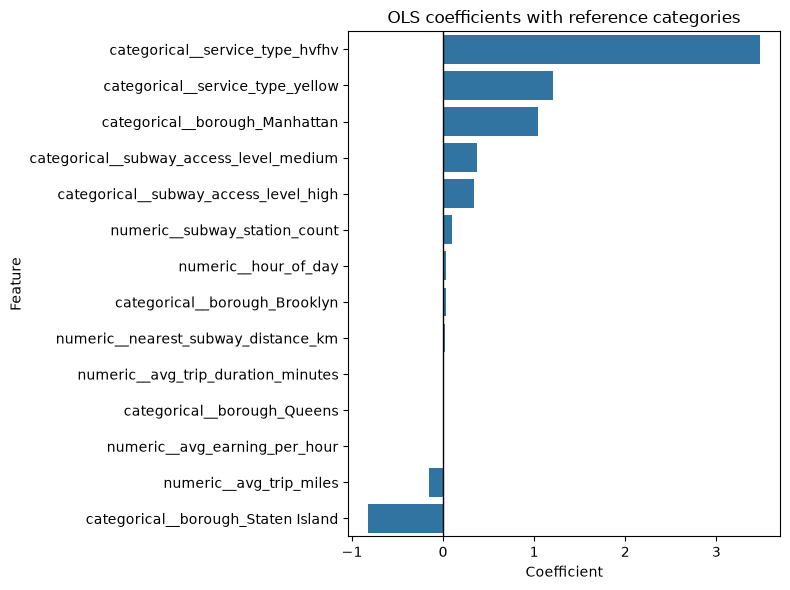

In [32]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=baseline_ols_coef,
    x="coefficient",
    y="feature",
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("OLS coefficients with reference categories")
plt.tight_layout()
plt.show()